<a href="https://colab.research.google.com/github/aansheeagrwal/Machine-learning/blob/main/Chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [ ]:
X_b = np.c_[np.ones((100, 1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [ ]:
theta_best

array([[4.28383121],
       [2.73377154]])

In [ ]:
X_new = np.array([[0], [2]])

In [ ]:
X_new_b = np.c_[np.ones((2, 1)), X_new]

In [ ]:
y_predict = X_new_b.dot(theta_best)

In [ ]:
y_predict

array([[4.28383121],
       [9.75137429]])

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LinearRegression


In [ ]:
lin_reg = LinearRegression()


In [ ]:
lin_reg.fit(X, y)


LinearRegression()

In [ ]:
lin_reg.intercept_, lin_reg.coef_


(array([4.28383121]), array([[2.73377154]]))

In [ ]:
lin_reg.predict(X_new)


array([[4.28383121],
       [9.75137429]])

In [ ]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)


In [ ]:
theta_best_svd


array([[4.28383121],
       [2.73377154]])

In [ ]:
np.linalg.pinv(X_b).dot(y)


array([[4.28383121],
       [2.73377154]])

In [ ]:
eta = 0.1  # learning rate
n_iterations = 1000
m = 100
theta = np.random.randn(2,1)  # random initialization
for iteration in range(n_iterations):

  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients
theta

array([[4.28383121],
       [2.73377154]])

In [ ]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters
def learning_schedule(t):
  return t0 / (t + t1)
theta = np.random.randn(2,1)  # random initialization
for epoch in range(n_epochs):
  for i in range(m):

    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch * m + i)
    theta = theta - eta * gradients

In [ ]:
theta

array([[4.31270552],
       [2.78059043]])

In [ ]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_


(array([4.27891381]), array([2.74332421]))

In [ ]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures


In [ ]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)


In [ ]:
X_poly = poly_features.fit_transform(X)


In [ ]:
X[0]


array([0.76804574])

In [ ]:
X_poly[0]


array([0.76804574, 0.58989426])

In [ ]:
lin_reg = LinearRegression()


In [ ]:
lin_reg.fit(X_poly, y)


LinearRegression()

In [ ]:
lin_reg.intercept_, lin_reg.coef_

(array([2.30175039]), array([[1.07057239, 0.46342662]]))

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_learning_curves(model, X, y):
 X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
 train_errors, val_errors = [], []
 for m in range(1, len(X_train)):
   model.fit(X_train[:m], y_train[:m])
   y_train_predict = model.predict(X_train[:m])

   y_val_predict = model.predict(X_val)
   train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
   val_errors.append(mean_squared_error(y_val, y_val_predict))
 plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
 plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

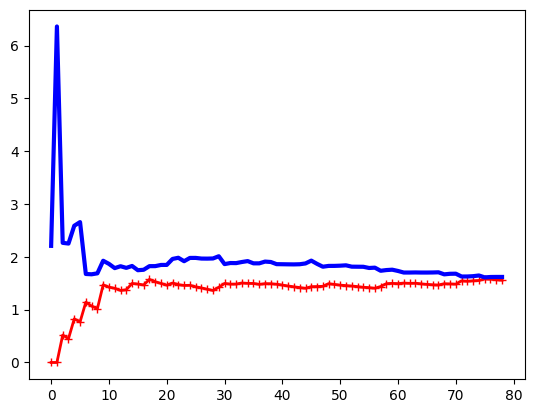

In [ ]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

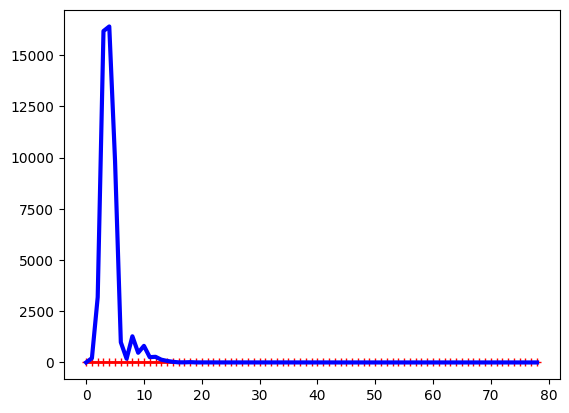

In [ ]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
 ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
 ("lin_reg", LinearRegression()),
 ])
plot_learning_curves(polynomial_regression, X, y)

In [ ]:
from sklearn.linear_model import Ridge


In [ ]:
ridge_reg = Ridge(alpha=1, solver="cholesky")


In [ ]:
ridge_reg.fit(X, y)


Ridge(alpha=1, solver='cholesky')

In [ ]:
ridge_reg.predict([[1.5]])


array([5.29057381])

In [ ]:
sgd_reg = SGDRegressor(penalty="l2")


In [ ]:
sgd_reg.fit(X, y.ravel())


SGDRegressor()

In [ ]:
sgd_reg.predict([[1.5]])


array([5.2644109])

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso_reg = Lasso(alpha=0.1)

In [ ]:
lasso_reg.fit(X, y)

Lasso(alpha=0.1)

In [ ]:
lasso_reg.predict([[1.5]])

array([5.24467854])

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [ ]:
elastic_net.fit(X, y)

ElasticNet(alpha=0.1)

In [ ]:
elastic_net.predict([[1.5]])

array([5.24496025])

In [ ]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# prepare the data
poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler()),
  ])

# Assuming X and y are already defined and split into train and validation sets
# If not, you would need to add those steps here:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005)

minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
  # Reshape y_train to be 1D for sgd_reg.fit
  sgd_reg.fit(X_train_poly_scaled, y_train.ravel()) # continues where it left off
  y_val_predict = sgd_reg.predict(X_val_poly_scaled)
  val_error = mean_squared_error(y_val, y_val_predict)
  if val_error < minimum_val_error:
    minimum_val_error = val_error
    best_epoch = epoch
    best_model = clone(sgd_reg)

print(f"Best epoch: {best_epoch}")
print(f"Minimum validation error: {minimum_val_error}")

Best epoch: 108
Minimum validation error: 0.9507477719479371


In [ ]:
from sklearn import datasets

In [ ]:
iris = datasets.load_iris()


In [ ]:
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [ ]:
X = iris["data"][:, 3:]

In [ ]:
y = (iris["target"] == 2).astype(int)  # 1 if Iris-Virginica, else 0

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, y)

LogisticRegression()

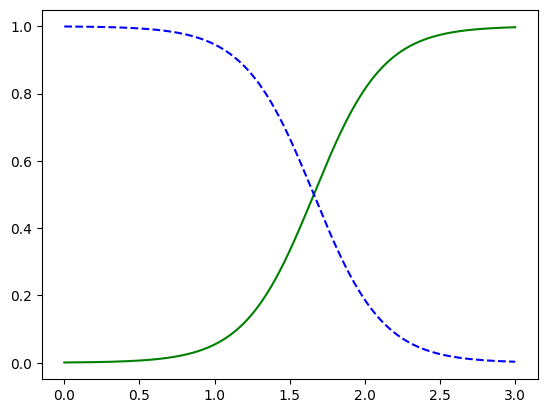

In [ ]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris-Virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris-Virginica")


In [ ]:
log_reg.predict([[1.7], [1.5]])


array([1, 0])

In [ ]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]
softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=10)
softmax_reg.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10, multi_class='multinomial')

In [ ]:
softmax_reg.predict([[5, 2]])


array([2])

In [ ]:
softmax_reg.predict_proba([[5, 2]])


array([[6.21626374e-07, 5.73689802e-02, 9.42630398e-01]])